**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [111]:
# Importing the required packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

Question 1

In [112]:
df = pd.read_csv('cardata.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Question 2

In [113]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [114]:
# Fixing Year column
# Creating a list of Years to categorize into each
years_2003_to_2007 = [2003,2004,2005,2006,2007]
years_2008_to_2012 = [2008,2009,2010,2011,2012]
years_2013_to_2018 = [2013,2014,2015,2016,2017,2018]
# Categorizing Make_Year into three categories
df['Year'] = df['Year'].apply(lambda x: "2003-2007" if x in years_2003_to_2007 else x)
df['Year'] = df['Year'].apply(lambda x: "2008-2012" if x in years_2008_to_2012 else x)
df['Year'] = df['Year'].apply(lambda x: "2013-2018" if x in years_2013_to_2018 else x)

In [115]:
# Fixing Fuel_Type column
df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Petrol' if x == "CNG" else x)

In [116]:
# Fixing Owners column
two_or_more = [1,3]
df['Owner'] = df['Owner'].apply(lambda x: '>0' if x in two_or_more else x)

<Axes: xlabel='Present_Price', ylabel='Density'>

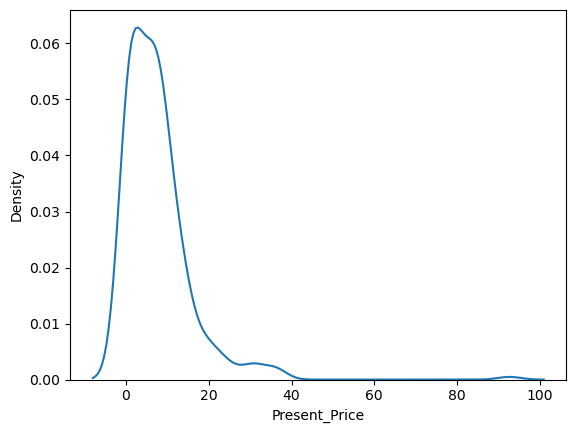

In [117]:
sns.kdeplot(data=df, x="Present_Price")

<Axes: xlabel='Selling_Price', ylabel='Density'>

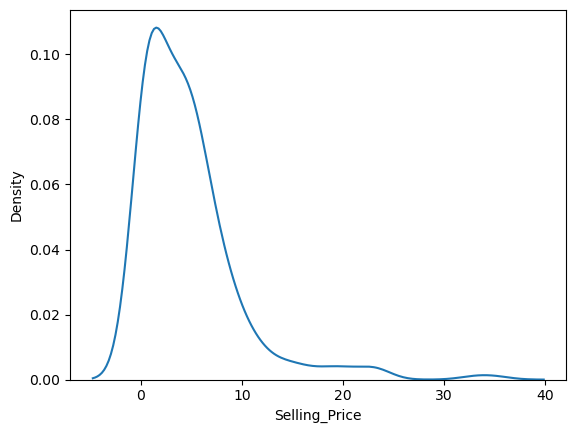

In [118]:
sns.kdeplot(data=df, x="Selling_Price")

<Axes: xlabel='Kms_Driven', ylabel='Density'>

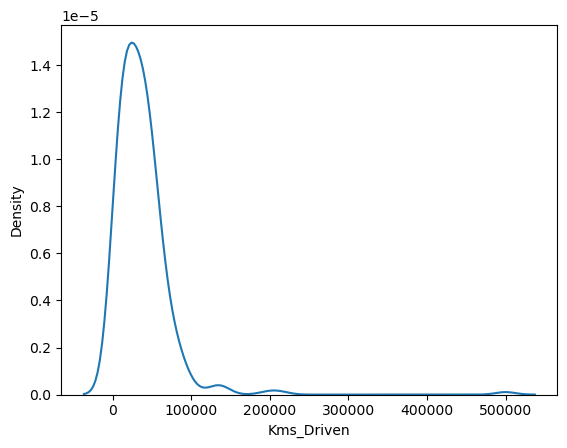

In [119]:
sns.kdeplot(data=df, x="Kms_Driven")

All three columns are skewed right so we need to log Kms_Driven and arcsin Selling_Price and Present_Price them so they are more normally distributed.

In [120]:
# Logging Kms_Driven column - only run this once
df['Kms_Driven'] = np.log(df['Kms_Driven'])

<Axes: xlabel='Kms_Driven', ylabel='Density'>

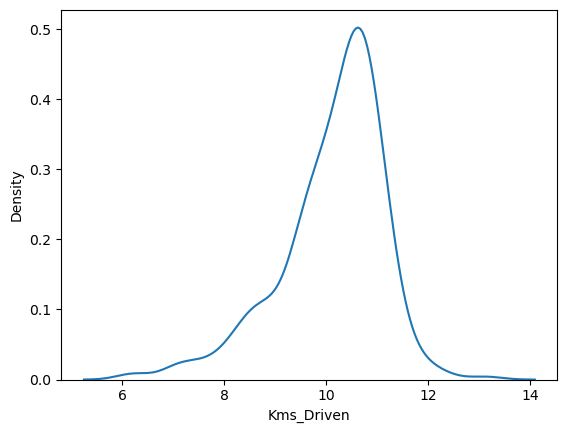

In [121]:
sns.kdeplot(data=df, x="Kms_Driven")

In [122]:
# Using arcsin to fix these numeric columns so they are more normally distributed and not bimodal (happened with log)
df[['Selling_Price','Present_Price']] = np.arcsinh(df[['Selling_Price','Present_Price']])

<Axes: xlabel='Present_Price', ylabel='Density'>

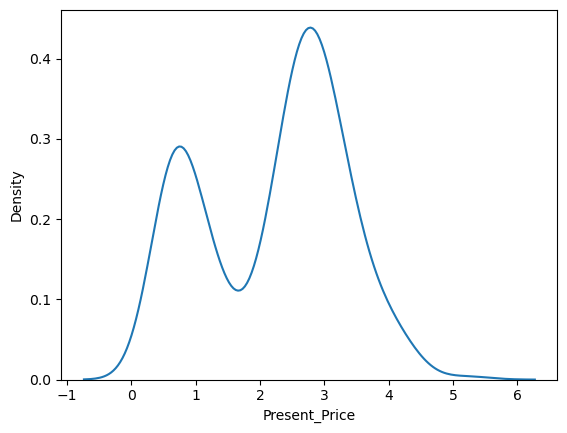

In [123]:
sns.kdeplot(data=df, x="Present_Price")

<Axes: xlabel='Selling_Price', ylabel='Density'>

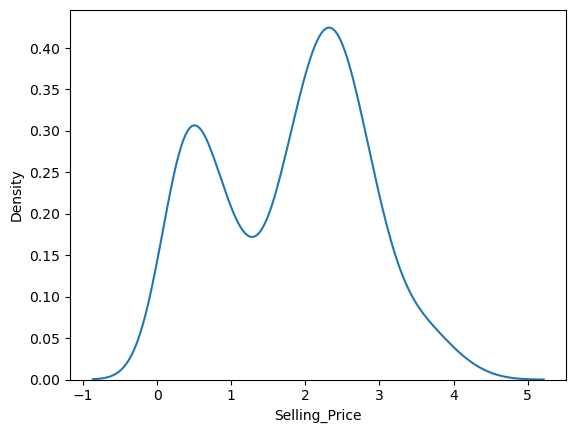

In [124]:
sns.kdeplot(data=df, x="Selling_Price")

My target is going to be Selling_Price and I am going to first use only Kms_Driven to predict this, but then I am going to include all features except Car_Name (which has far too many car names to be useful).

Question 3

In [165]:
def split(df, features, target):
    # Selecting features and preparing arrays for split
    X = df[features].dropna()
    
    # use the same target variable, but drop rows with missing features
    y = df.loc[X.index, target]
    
    # Training and testing data split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
        
    # Creating Linear Regression model on the training data
    model = LinearRegression().fit(X_train, y_train)
    
    # Predicting values to calculate RMSE
    y_pred = model.predict(X_test)
    
    # Calculate and print RMSE and R²
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"R Squared Error: {r2}\nRoot Mean Squared Error: {rmse}")
    return y_pred, y_test

In [166]:
# Using just Present_Price and Kms_Driven is a somewhat successful model,
# but Present_Price might be too correlated with Selling_Price
y_pred1, y_test1 = split(df, ['Present_Price','Kms_Driven'], 'Selling_Price')

R Squared Error: 0.9294743565590645
Root Mean Squared Error: 0.2731216209467821


In [167]:
# One-hot encoding - need to drop first column to avoid multicollinearity this time
to_cat = list(df.select_dtypes('object'))
df_encoded = pd.get_dummies(df, columns = to_cat[1:], drop_first = True)

In [168]:
# Trying with just categorical variables
y_pred2, y_true2 = split(df_encoded, ['Year_2008-2012', 'Year_2013-2018', 'Fuel_Type_Petrol',
                   'Seller_Type_Individual', 'Transmission_Manual', 'Owner_>0'], 
                   'Selling_Price')

R Squared Error: 0.8300225123544538
Root Mean Squared Error: 0.4240121053044277


In [169]:
# Trying with all variables previously except Present_Price
y_pred3, y_true3 = split(df_encoded, ['Year_2008-2012', 'Year_2013-2018', 'Fuel_Type_Petrol',
                   'Seller_Type_Individual', 'Transmission_Manual', 'Owner_>0', 'Kms_Driven'], 
                   'Selling_Price')

R Squared Error: 0.8334929449986946
Root Mean Squared Error: 0.4196612525032723


In [170]:
# Trying with specifically Years and Kms_Driven - this is a horrible model
y_pred4, y_true4 = split(df_encoded, ['Year_2008-2012', 'Year_2013-2018', 'Kms_Driven'], 
                   'Selling_Price')

R Squared Error: 0.0039037230079859153
Root Mean Squared Error: 1.0264391565886415


In [171]:
# Using just Present_Price - doesn't seem too correlated, just a good predictor
y_pred5, y_test5 = split(df, ['Present_Price'], 'Selling_Price')

R Squared Error: 0.9089641191285514
Root Mean Squared Error: 0.31030505617171183


Question 5

The best model was the first one using Present_Price and Kms_Driven to predict Selling_Price with an R squared error of 0.9294 and an RMSE of 0.2731. I believe this model performed the best because it was simple and used the other numeric variables in the dataset effectively to predict Selling_Price.

Question 6

I learned that even though I have many columns, including many categorical variables, they are not necessarily helpful in predicting a numeric target variable. In addition, ensuring that the numeric variables were not skewed, and fixing them because they were, was helpful in ensuring the model was accurate.